<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/LLM_Agent_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 LLM Agent 실전 도구 활용 노트북

> **"AI가 단순히 답변만 하는 게 아니라, 실제로 '일'을 하게 만들기!"**

## 🌟 이 노트북에서 만들 것

LLM Agent란 **AI가 외부 도구를 자율적으로 사용하는 시스템**입니다.

### 🛠️ 실제로 사용할 외부 도구 8가지

| 도구 | 데이터 출처 | API 키 필요? |
|------|------------|------------|
| ⏰ **시간/날짜** | Python 내장 | ❌ |
| 🌤️ **날씨** | wttr.in | ❌ |
| 📈 **주식** | Yahoo Finance | ❌ |
| 📰 **뉴스** | Google News RSS | ❌ |
| 💱 **환율** | 무료 환율 API | ❌ |
| 💰 **암호화폐** | CoinGecko | ❌ |
| 🔍 **웹 검색** | DuckDuckGo | ❌ |
| 📚 **위키백과** | Wikipedia API | ❌ |

> 🎉 **모든 도구가 API 키 없이 작동!** 누구나 즉시 학습 가능

## 📌 이 노트북의 특징

- ✅ **실제 외부 API 호출** (시뮬레이션이 아닌 진짜!)
- ✅ **모든 도구 무료** (API 키 불필요)
- ✅ **LangGraph로 통합 Agent** 구축
- ✅ **AI가 스스로 도구 선택** 시연
- ✅ **다중 도구 사용** 복잡한 작업

> 💡 **선수 학습 권장**: LangChain 노트북 (시리즈 9번)

---

## 📚 전체 목차

| 섹션 | 제목 | 내용 |
|------|------|------|
| 1 | 🛠️ 환경 설정 | 라이브러리 + LLM 준비 |
| 2 | 🤔 Agent란? | 개념 + 작동 원리 |
| 3 | ⏰ 시간/날짜 도구 | 첫 도구 만들기 |
| 4 | 🌤️ 날씨 도구 | wttr.in 활용 |
| 5 | 📈 주식 도구 | Yahoo Finance |
| 6 | 📰 뉴스 도구 | Google News RSS |
| 7 | 💱 환율 도구 | 실시간 환율 |
| 8 | 💰 암호화폐 도구 | CoinGecko |
| 9 | 🔍 웹 검색 도구 | DuckDuckGo |
| 10 | 📚 위키백과 도구 | Wikipedia |
| 11 | 🤖 통합 Agent | LangGraph ReAct |
| 12 | 🎯 복합 시나리오 | 다중 도구 활용 |
| 13 | ⚠️ 함정과 모범 사례 | 실전 팁 |
| 14 | 🎓 최종 정리 | 다음 단계 |


---
# 1️⃣ 환경 설정 🛠️

## 📦 필요한 라이브러리

| 카테고리 | 라이브러리 | 용도 |
|---------|----------|------|
| **Agent 프레임워크** | `langchain`, `langgraph` | 도구 통합 |
| **LLM** | `langchain-openai` | ChatGPT |
| **시간** | `pytz` | 시간대 처리 |
| **주식** | `yfinance` | Yahoo Finance 데이터 |
| **뉴스** | `feedparser` | RSS 피드 파싱 |
| **검색** | `duckduckgo-search` | 웹 검색 |
| **위키** | `wikipedia-api` | 위키피디아 |
| **HTTP** | `requests` | 일반 API 호출 |

In [1]:
# 📦 라이브러리 설치
!pip install -q langchain langchain-core langchain-community langchain-openai
!pip install -q langgraph
!pip install -q yfinance pytz feedparser
!pip install -q duckduckgo-search wikipedia-api

print("✅ 모든 라이브러리 설치 완료!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 

In [2]:
# 📚 기본 import
import os
import json
import requests
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.font_manager as fm

# 한글 폰트 (Colab용)
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("✅ 기본 환경 준비 완료!")

✅ 기본 환경 준비 완료!


In [3]:
# 🔑 OpenAI API 키 설정 (Agent의 두뇌 역할)
try:
    from google.colab import userdata

    def get_secret(key_name, default=""):
        try:
            return userdata.get(key_name)
        except Exception:
            return default
except ImportError:
    def get_secret(key_name, default=""):
        return os.environ.get(key_name, default)

OPENAI_API_KEY = get_secret('OPENAI_API_KEY', '')

if OPENAI_API_KEY:
    os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
    LLM_AVAILABLE = True
    print("✅ OpenAI API 키 준비됨 - 실제 Agent 작동")
else:
    LLM_AVAILABLE = False
    print("⚠️ OpenAI API 키 미설정")
    print("💡 도구들은 실제로 작동하지만, Agent는 시뮬레이션 모드")
    print("💡 좌측 🔑 아이콘에서 OPENAI_API_KEY 추가 권장")

⚠️ OpenAI API 키 미설정
💡 도구들은 실제로 작동하지만, Agent는 시뮬레이션 모드
💡 좌측 🔑 아이콘에서 OPENAI_API_KEY 추가 권장


---
# 2️⃣ Agent란 무엇인가? 🤔

## 🎯 일반 LLM vs Agent

### 일반 LLM (정적 지식)
```
👤 "오늘 서울 날씨 어때?"
🤖 "저는 실시간 정보에 접근할 수 없습니다..."
```
→ LLM은 학습 데이터까지만 알고, **현재 상황은 모름**

### LLM Agent (도구 사용)
```
👤 "오늘 서울 날씨 어때?"
🤖 (생각) "weather 도구를 써야겠다"
🔧 [get_weather("서울") 호출] → "맑음, 12도"
🤖 "오늘 서울은 맑고 12도입니다!"
```
→ Agent는 **외부 세계와 상호작용** 가능

## 🧠 Agent의 핵심 개념: ReAct (Reasoning + Acting)

```
1. Reason (생각): 어떤 도구가 필요한가?
   ↓
2. Act (행동): 도구를 호출
   ↓
3. Observe (관찰): 결과 확인
   ↓
4. Repeat: 충분한 정보가 모일 때까지 반복
   ↓
5. Answer: 최종 답변 생성
```

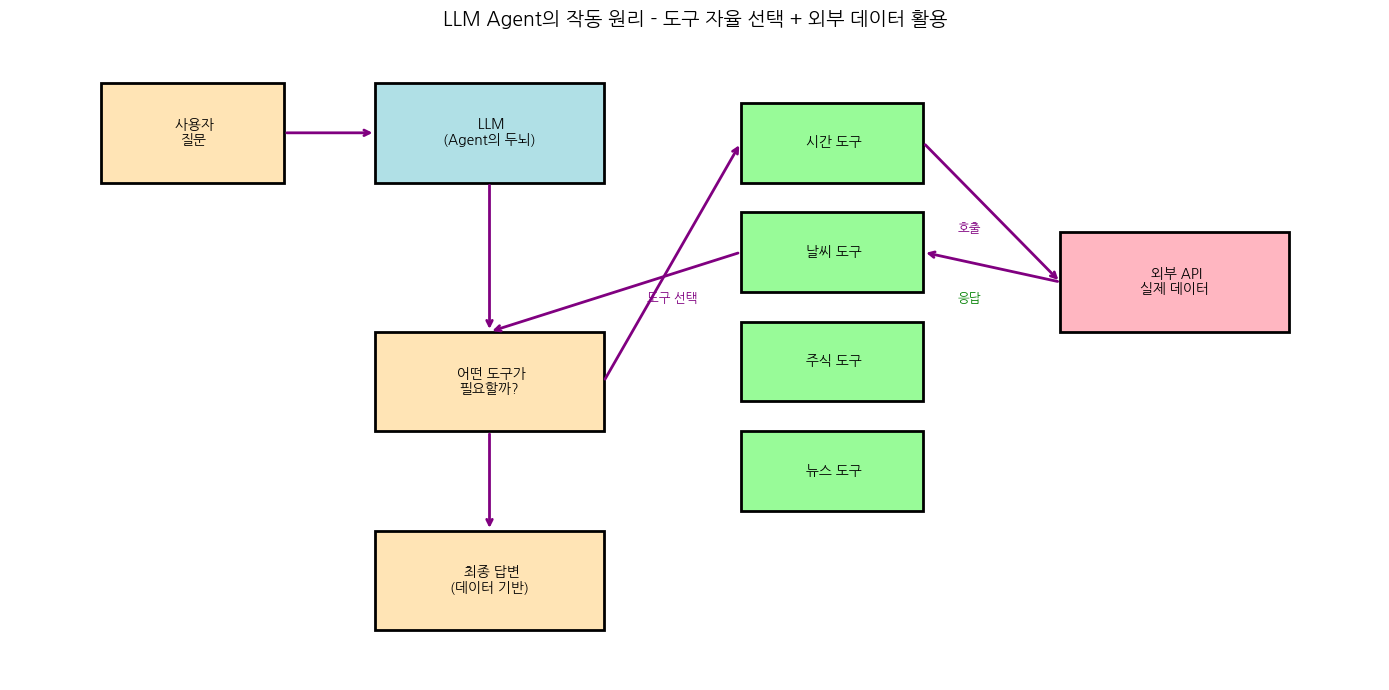


💡 Agent의 진정한 가치:
   • LLM의 추론 능력 + 실시간 외부 데이터
   • 사용자는 어떤 도구를 쓸지 몰라도 됨 (자율 선택)
   • 여러 도구를 조합하여 복잡한 작업 가능


In [4]:
# 🎨 Agent 작동 원리 시각화
fig, ax = plt.subplots(figsize=(14, 7))

# 박스 정의
boxes = [
    (1, 5.5, 2, 1, ' 사용자\n질문', '#FFE4B5'),
    (4, 5.5, 2.5, 1, ' LLM\n(Agent의 두뇌)', '#B0E0E6'),
    (4, 3, 2.5, 1, ' 어떤 도구가\n필요할까?', '#FFE4B5'),
    (8, 5.5, 2, 0.8, ' 시간 도구', '#98FB98'),
    (8, 4.4, 2, 0.8, ' 날씨 도구', '#98FB98'),
    (8, 3.3, 2, 0.8, ' 주식 도구', '#98FB98'),
    (8, 2.2, 2, 0.8, ' 뉴스 도구', '#98FB98'),
    (11.5, 4, 2.5, 1, ' 외부 API\n실제 데이터', '#FFB6C1'),
    (4, 1, 2.5, 1, ' 최종 답변\n(데이터 기반)', '#FFE4B5'),
]

for x, y, w, h, text, color in boxes:
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color,
                                 edgecolor='black', linewidth=2))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold')

# 화살표
arrows = [
    ((3, 6), (4, 6)),           # 사용자 → LLM
    ((5.25, 5.5), (5.25, 4)),   # LLM → 생각
    ((6.5, 3.5), (8, 5.9)),     # 도구 선택
    ((10, 5.9), (11.5, 4.5)),   # 도구 → API
    ((11.5, 4.5), (10, 4.8)),   # API → 도구 (결과)
    ((8, 4.8), (5.25, 4)),      # 도구 결과 → 다시 LLM
    ((5.25, 3), (5.25, 2)),     # LLM → 답변
]

for (xs, ys), (xe, ye) in arrows:
    ax.annotate('', xy=(xe, ye), xytext=(xs, ys),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2))

# 텍스트 라벨
ax.text(7.25, 4.3, '도구 선택', ha='center', fontsize=9, color='purple', style='italic')
ax.text(10.5, 5.0, '호출', ha='center', fontsize=9, color='purple', style='italic')
ax.text(10.5, 4.3, '응답', ha='center', fontsize=9, color='green', style='italic')

ax.set_xlim(0, 15)
ax.set_ylim(0.5, 7)
ax.axis('off')
ax.set_title('LLM Agent의 작동 원리 - 도구 자율 선택 + 외부 데이터 활용',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Agent의 진정한 가치:")
print("   • LLM의 추론 능력 + 실시간 외부 데이터")
print("   • 사용자는 어떤 도구를 쓸지 몰라도 됨 (자율 선택)")
print("   • 여러 도구를 조합하여 복잡한 작업 가능")

---
# 3️⃣ 시간/날짜 도구 ⏰

## 🎯 가장 단순한 도구부터 시작

시간 정보는 LLM이 절대 알 수 없는 정보예요! (학습 시점에 고정됨)

### 📋 도구 사양
- **이름**: `get_current_time`
- **입력**: 도시 (서울, 도쿄, 뉴욕 등)
- **출력**: 해당 도시의 현재 시간
- **데이터 출처**: Python `datetime` + `pytz` (외부 API 불필요)

In [5]:
# ⏰ 시간/날짜 도구 - 단독으로 먼저 동작 확인
import pytz
from datetime import datetime

# 1. 단순한 함수로 만들기 (Tool 만들기 전 단계)
def get_time(city: str = "Seoul") -> dict:
    """특정 도시의 현재 시간을 조회"""

    # 도시명 → 시간대 매핑
    city_timezones = {
        "서울": "Asia/Seoul",
        "seoul": "Asia/Seoul",
        "도쿄": "Asia/Tokyo",
        "tokyo": "Asia/Tokyo",
        "뉴욕": "America/New_York",
        "new york": "America/New_York",
        "런던": "Europe/London",
        "london": "Europe/London",
        "파리": "Europe/Paris",
        "paris": "Europe/Paris",
        "베이징": "Asia/Shanghai",
        "beijing": "Asia/Shanghai",
        "두바이": "Asia/Dubai",
        "dubai": "Asia/Dubai",
    }

    tz_name = city_timezones.get(city.lower(), "Asia/Seoul")  # 기본: 서울

    try:
        tz = pytz.timezone(tz_name)
        now = datetime.now(tz)

        return {
            "city": city,
            "timezone": tz_name,
            "current_time": now.strftime("%Y-%m-%d %H:%M:%S"),
            "weekday": now.strftime("%A"),
            "weekday_kr": ["월", "화", "수", "목", "금", "토", "일"][now.weekday()] + "요일",
            "iso": now.isoformat()
        }
    except Exception as e:
        return {"error": str(e)}

# 단독 테스트
print("⏰ 시간 도구 단독 테스트")
print("=" * 60)
for city in ["서울", "뉴욕", "런던", "도쿄"]:
    result = get_time(city)
    print(f"\n🏙️ {city}:")
    print(f"   📅 {result['current_time']} ({result['weekday_kr']})")
    print(f"   🌐 시간대: {result['timezone']}")

⏰ 시간 도구 단독 테스트

🏙️ 서울:
   📅 2026-05-15 15:57:15 (금요일)
   🌐 시간대: Asia/Seoul

🏙️ 뉴욕:
   📅 2026-05-15 02:57:15 (금요일)
   🌐 시간대: America/New_York

🏙️ 런던:
   📅 2026-05-15 07:57:15 (금요일)
   🌐 시간대: Europe/London

🏙️ 도쿄:
   📅 2026-05-15 15:57:15 (금요일)
   🌐 시간대: Asia/Tokyo


In [6]:
# 🛠️ 이제 LangChain Tool로 변환 (@tool 데코레이터)
from langchain_core.tools import tool

@tool
def get_current_time(city: str = "Seoul") -> str:
    """특정 도시의 현재 시간과 요일을 조회합니다.

    Args:
        city: 도시 이름 (한국어 또는 영어).
              지원: 서울, 도쿄, 뉴욕, 런던, 파리, 베이징, 두바이

    Returns:
        해당 도시의 현재 날짜·시간·요일 정보 문자열
    """
    result = get_time(city)
    if "error" in result:
        return f"오류: {result['error']}"

    return (f"{city}의 현재 시간: {result['current_time']} "
            f"({result['weekday_kr']}, 시간대: {result['timezone']})")

# Tool 정보 확인
print("🔧 Tool 정보:")
print(f"   이름: {get_current_time.name}")
print(f"   설명: {get_current_time.description.split(chr(10))[0]}")
print(f"   인자: {get_current_time.args}")

# Tool 직접 호출 (Agent 없이도 동작)
print("\n🎯 Tool 직접 호출:")
print(get_current_time.invoke("서울"))
print(get_current_time.invoke("뉴욕"))

🔧 Tool 정보:
   이름: get_current_time
   설명: 특정 도시의 현재 시간과 요일을 조회합니다.
   인자: {'city': {'default': 'Seoul', 'title': 'City', 'type': 'string'}}

🎯 Tool 직접 호출:
서울의 현재 시간: 2026-05-15 15:58:50 (금요일, 시간대: Asia/Seoul)
뉴욕의 현재 시간: 2026-05-15 02:58:50 (금요일, 시간대: America/New_York)


## 💡 @tool 데코레이터의 마법

```python
@tool
def get_current_time(city: str = "Seoul") -> str:
    """이 docstring이 LLM에게 사용법 알려줌"""
    ...
```

**자동으로 일어나는 일**:
1. 일반 Python 함수 → LangChain Tool 객체로 변환
2. **docstring** → LLM이 "이 도구가 뭐 하는지" 이해
3. **타입 힌트** → LLM이 "어떤 인자 넣을지" 결정
4. **함수 이름** → tool 이름으로 자동 설정

> 💡 LLM은 코드를 보지 않습니다. **docstring과 타입 힌트만 봐요!**

### ✅ 체크포인트 1

지금까지:
- ✅ 환경 설정 + 라이브러리
- ✅ Agent의 핵심 개념 (Reason + Act)
- ✅ 첫 도구 (시간/날짜) 만들기
- ✅ `@tool` 데코레이터 사용법

다음은 **진짜 외부 API**를 호출하는 도구들! 🌐

---
# 4️⃣ 날씨 도구 🌤️

## 🎯 wttr.in - API 키 없는 무료 날씨 서비스

### 📋 도구 사양
- **데이터 출처**: wttr.in (World Weather Online 기반)
- **API 키**: 불필요! ❌
- **사용법**: `https://wttr.in/{도시}?format=j1` → JSON 응답
- **무료**: 일정 요청 제한 내 무료

### 🔗 wttr.in이 특별한 이유
- 명령줄에서도 사용 가능: `curl wttr.in/Seoul`
- 다양한 출력 포맷 (텍스트, JSON, ANSI 색상 등)
- 한글 도시명도 지원

In [7]:
# 🌤️ 날씨 도구 - wttr.in 사용
def fetch_weather(city: str) -> dict:
    """wttr.in에서 날씨 정보 가져오기"""
    try:
        url = f"https://wttr.in/{city}?format=j1"
        response = requests.get(url, timeout=10,
                                headers={'User-Agent': 'curl/7.0'})
        response.raise_for_status()
        data = response.json()

        # 현재 날씨 정보 추출
        current = data['current_condition'][0]

        # 한국어 날씨 설명 (영어 번역)
        weather_kr = current.get('lang_ko', [{}])[0].get('value', current['weatherDesc'][0]['value'])

        return {
            "city": city,
            "temp_c": current['temp_C'],
            "feels_like_c": current['FeelsLikeC'],
            "humidity": current['humidity'],
            "weather_desc": weather_kr,
            "wind_kmh": current['windspeedKmph'],
            "wind_dir": current.get('winddir16Point', '?'),
            "pressure": current.get('pressure', '?'),
            "uv_index": current.get('uvIndex', '?'),
            "visibility": current.get('visibility', '?'),
        }
    except requests.exceptions.RequestException as e:
        return {"error": f"날씨 조회 실패: {str(e)}"}
    except Exception as e:
        return {"error": f"파싱 오류: {str(e)}"}

# 단독 테스트
print("🌤️ 날씨 도구 단독 테스트")
print("=" * 60)
for city in ["Seoul", "Tokyo", "New York"]:
    result = fetch_weather(city)
    if "error" in result:
        print(f"\n🏙️ {city}: ❌ {result['error']}")
    else:
        print(f"\n🏙️ {city}:")
        print(f"   🌡️ 기온: {result['temp_c']}°C (체감 {result['feels_like_c']}°C)")
        print(f"   ☁️ 날씨: {result['weather_desc']}")
        print(f"   💧 습도: {result['humidity']}%")
        print(f"   💨 바람: {result['wind_kmh']} km/h ({result['wind_dir']})")

🌤️ 날씨 도구 단독 테스트

🏙️ Seoul:
   🌡️ 기온: 29°C (체감 28°C)
   ☁️ 날씨: Sunny
   💧 습도: 43%
   💨 바람: 11 km/h (W)

🏙️ Tokyo:
   🌡️ 기온: 20°C (체감 20°C)
   ☁️ 날씨: Sunny
   💧 습도: 68%
   💨 바람: 29 km/h (ENE)

🏙️ New York:
   🌡️ 기온: 12°C (체감 10°C)
   ☁️ 날씨: Cloudy
   💧 습도: 63%
   💨 바람: 15 km/h (NW)


In [8]:
# 🛠️ Tool로 변환
@tool
def get_weather(city: str) -> str:
    """특정 도시의 현재 날씨 정보를 조회합니다.
    온도, 습도, 바람, 날씨 상태 등 상세 정보를 반환합니다.

    Args:
        city: 도시 이름 (예: 'Seoul', 'Tokyo', 'New York', '서울', '부산')

    Returns:
        해당 도시의 현재 날씨 상세 정보 문자열
    """
    result = fetch_weather(city)

    if "error" in result:
        return f"⚠️ {result['error']}"

    return (
        f"{result['city']}의 현재 날씨:\n"
        f"- 기온: {result['temp_c']}°C (체감 {result['feels_like_c']}°C)\n"
        f"- 상태: {result['weather_desc']}\n"
        f"- 습도: {result['humidity']}%\n"
        f"- 바람: {result['wind_kmh']} km/h {result['wind_dir']}\n"
        f"- UV지수: {result['uv_index']}, 가시거리: {result['visibility']}km"
    )

# Tool 직접 호출
print("🎯 get_weather Tool 테스트:")
print(get_weather.invoke("Seoul"))
print()
print(get_weather.invoke("London"))

🎯 get_weather Tool 테스트:
Seoul의 현재 날씨:
- 기온: 29°C (체감 28°C)
- 상태: Sunny
- 습도: 43%
- 바람: 11 km/h W
- UV지수: 6, 가시거리: 10km

London의 현재 날씨:
- 기온: 5°C (체감 3°C)
- 상태: Overcast
- 습도: 93%
- 바람: 10 km/h NNW
- UV지수: 0, 가시거리: 10km


---
# 5️⃣ 주식 도구 📈

## 🎯 yfinance - Yahoo Finance 데이터

### 📋 도구 사양
- **데이터 출처**: Yahoo Finance (yfinance Python 라이브러리)
- **API 키**: 불필요! ❌
- **무료**: 완전 무료 (yfinance가 비공식 API 사용)
- **데이터**: 주가, 거래량, 변동률, 시가총액 등

### ⚠️ 주의사항
- 데이터는 **15-20분 지연** (실시간 아님)
- 비공식 라이브러리 (Yahoo가 언제든 막을 수 있음)
- **상업적 사용은 별도 검토 필요**
- 학습/개인용으로는 최고!

### 📊 주요 티커 예시
- 미국 주식: `AAPL` (애플), `GOOGL` (구글), `MSFT` (마이크로소프트), `TSLA` (테슬라)
- 한국 주식: `005930.KS` (삼성전자), `000660.KS` (SK하이닉스)
- 지수: `^GSPC` (S&P 500), `^IXIC` (나스닥)

In [9]:
# 📈 주식 도구 - yfinance
import yfinance as yf

def fetch_stock_info(ticker: str) -> dict:
    """yfinance로 주식 정보 가져오기"""
    try:
        stock = yf.Ticker(ticker)
        info = stock.info

        # 최근 1일 가격 데이터
        hist = stock.history(period="2d")

        if hist.empty:
            return {"error": f"'{ticker}' 데이터를 찾을 수 없습니다"}

        # 현재 가격 (가장 최근)
        current_price = hist['Close'].iloc[-1]

        # 전일 가격 (변동률 계산용)
        if len(hist) >= 2:
            prev_price = hist['Close'].iloc[-2]
            change = current_price - prev_price
            change_pct = (change / prev_price) * 100
        else:
            change = 0
            change_pct = 0

        return {
            "ticker": ticker,
            "name": info.get('longName', info.get('shortName', ticker)),
            "current_price": round(current_price, 2),
            "currency": info.get('currency', 'USD'),
            "change": round(change, 2),
            "change_pct": round(change_pct, 2),
            "day_high": round(hist['High'].iloc[-1], 2),
            "day_low": round(hist['Low'].iloc[-1], 2),
            "volume": int(hist['Volume'].iloc[-1]),
            "market_cap": info.get('marketCap', None),
            "sector": info.get('sector', 'N/A'),
        }
    except Exception as e:
        return {"error": f"주식 조회 실패: {str(e)}"}

# 단독 테스트
print("📈 주식 도구 단독 테스트")
print("=" * 60)

for ticker in ["AAPL", "TSLA", "005930.KS"]:  # 애플, 테슬라, 삼성전자
    print(f"\n📊 {ticker}:")
    result = fetch_stock_info(ticker)
    if "error" in result:
        print(f"   ❌ {result['error']}")
    else:
        arrow = "▲" if result['change'] > 0 else ("▼" if result['change'] < 0 else "─")
        print(f"   회사: {result['name']}")
        print(f"   현재가: {result['current_price']:,} {result['currency']}")
        print(f"   변동: {arrow} {abs(result['change'])} ({result['change_pct']:+.2f}%)")
        print(f"   거래량: {result['volume']:,}주")
        if result['market_cap']:
            print(f"   시가총액: ${result['market_cap']/1e9:.2f}B")

📈 주식 도구 단독 테스트

📊 AAPL:
   회사: Apple Inc.
   현재가: 298.21 USD
   변동: ▼ 0.66 (-0.22%)
   거래량: 35,263,400주
   시가총액: $4379.92B

📊 TSLA:
   회사: Tesla, Inc.
   현재가: 443.3 USD
   변동: ▼ 1.97 (-0.44%)
   거래량: 45,939,400주
   시가총액: $1664.91B

📊 005930.KS:
   회사: Samsung Electronics Co., Ltd.
   현재가: 270,500.0 KRW
   변동: ▼ 25500.0 (-8.61%)
   거래량: 39,923,280주
   시가총액: $1776255.40B


In [11]:
# 🛠️ Tool로 변환
@tool
def get_stock_price(ticker: str) -> str:
    """주식 현재가, 변동률, 거래량 등을 조회합니다.

    티커 예시:
    - 미국: AAPL (애플), GOOGL (구글), MSFT (마이크로소프트), TSLA (테슬라), NVDA (엔비디아)
    - 한국: 005930.KS (삼성전자), 000660.KS (SK하이닉스)
    - 지수: ^GSPC (S&P 500), ^IXIC (나스닥)

    Args:
        ticker: 주식 티커 심볼 (대소문자 구분, 한국 주식은 .KS 또는 .KQ 접미사)

    Returns:
        주식 정보 (현재가, 변동률, 거래량 등) 문자열
    """
    result = fetch_stock_info(ticker)

    if "error" in result:
        return f"⚠️ {result['error']}"

    arrow = "▲" if result['change'] > 0 else ("▼" if result['change'] < 0 else "─")
    market_cap_str = ""
    if result['market_cap']:
        market_cap_str = f"\n- 시가총액: ${result['market_cap']/1e9:.2f}B"

    return (
        f"{result['name']} ({result['ticker']}):\n"
        f"- 현재가: {result['current_price']:,} {result['currency']}\n"
        f"- 변동: {arrow} {abs(result['change'])} ({result['change_pct']:+.2f}%)\n"
        f"- 일중 고가/저가: {result['day_high']:,} / {result['day_low']:,}\n"
        f"- 거래량: {result['volume']:,}주\n"
        f"- 섹터: {result['sector']}{market_cap_str}"
    )

# Tool 테스트
print("🎯 get_stock_price Tool 테스트:")
print(get_stock_price.invoke("AAPL"))
print()
print(get_stock_price.invoke("005930.KS"))

🎯 get_stock_price Tool 테스트:
Apple Inc. (AAPL):
- 현재가: 298.21 USD
- 변동: ▼ 0.66 (-0.22%)
- 일중 고가/저가: 300.45 / 295.38
- 거래량: 35,263,400주
- 섹터: Technology
- 시가총액: $4379.92B

Samsung Electronics Co., Ltd. (005930.KS):
- 현재가: 270,500.0 KRW
- 변동: ▼ 25500.0 (-8.61%)
- 일중 고가/저가: 296,500.0 / 266,000.0
- 거래량: 39,923,280주
- 섹터: Technology
- 시가총액: $1776255.40B


## 🎨 주식 시각화 보너스

📊 애플(AAPL) 1개월 차트:


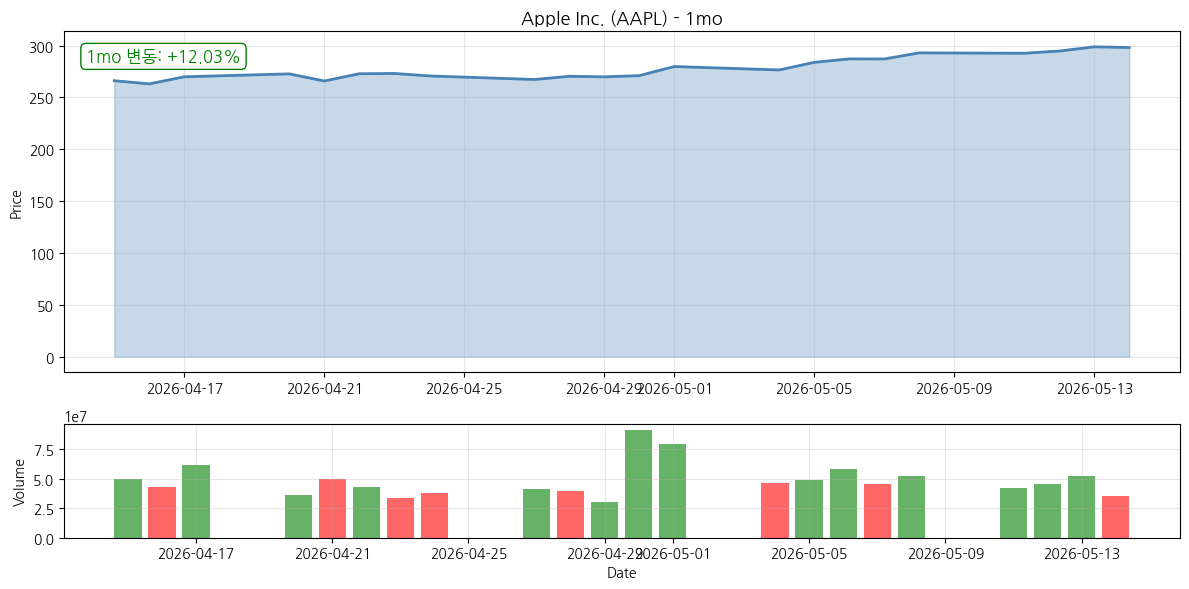

In [12]:
# 📊 보너스: 주식 차트 그리기
import yfinance as yf

def plot_stock_chart(ticker: str, period: str = "1mo"):
    """주식 차트 그리기"""
    stock = yf.Ticker(ticker)
    hist = stock.history(period=period)
    info = stock.info
    name = info.get('longName', ticker)

    if hist.empty:
        print(f"⚠️ {ticker} 데이터 없음")
        return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),
                                     gridspec_kw={'height_ratios': [3, 1]})

    # 가격 차트
    ax1.plot(hist.index, hist['Close'], color='steelblue', linewidth=2)
    ax1.fill_between(hist.index, hist['Close'], alpha=0.3, color='steelblue')
    ax1.set_title(f'{name} ({ticker}) - {period}', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Price')
    ax1.grid(True, alpha=0.3)

    # 변동률 표시
    pct_change = ((hist['Close'].iloc[-1] - hist['Close'].iloc[0]) / hist['Close'].iloc[0]) * 100
    color = 'green' if pct_change >= 0 else 'red'
    ax1.text(0.02, 0.95, f'{period} 변동: {pct_change:+.2f}%',
             transform=ax1.transAxes, fontsize=12, fontweight='bold',
             color=color, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor=color))

    # 거래량 차트
    colors_vol = ['green' if hist['Close'].iloc[i] >= hist['Open'].iloc[i] else 'red'
                   for i in range(len(hist))]
    ax2.bar(hist.index, hist['Volume'], color=colors_vol, alpha=0.6)
    ax2.set_ylabel('Volume')
    ax2.set_xlabel('Date')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 차트 보기
print("📊 애플(AAPL) 1개월 차트:")
plot_stock_chart("AAPL", period="1mo")

---
# 6️⃣ 뉴스 도구 📰

## 🎯 Google News RSS - API 키 없는 뉴스 검색

### 📋 도구 사양
- **데이터 출처**: Google News RSS 피드
- **API 키**: 불필요! ❌
- **장점**: 전 세계 뉴스, 다국어 지원
- **사용법**: `https://news.google.com/rss/search?q={검색어}`

### 🔄 RSS란?
**R**eally **S**imple **S**yndication - 뉴스 사이트들이 표준화된 형식으로 새 글을 발행하는 방식
- 거의 모든 뉴스 사이트에 RSS 있음
- `feedparser` 라이브러리로 쉽게 파싱

In [13]:
# 📰 뉴스 도구 - Google News RSS
import feedparser
from urllib.parse import quote

def fetch_news(query: str, max_results: int = 5, hl: str = "ko", gl: str = "KR") -> dict:
    """Google News RSS에서 뉴스 검색

    Args:
        query: 검색어
        max_results: 최대 결과 수
        hl: 언어 (ko: 한국어, en: 영어)
        gl: 국가 (KR: 한국, US: 미국)
    """
    try:
        # URL 인코딩
        encoded_query = quote(query)
        url = (f"https://news.google.com/rss/search?"
                f"q={encoded_query}&hl={hl}&gl={gl}&ceid={gl}:{hl}")

        feed = feedparser.parse(url)

        if not feed.entries:
            return {"error": f"'{query}'에 대한 뉴스를 찾을 수 없습니다."}

        articles = []
        for entry in feed.entries[:max_results]:
            # 제목에서 출처 분리 (Google News는 "제목 - 출처" 형식)
            title = entry.title
            source = ""
            if " - " in title:
                parts = title.rsplit(" - ", 1)
                title = parts[0]
                source = parts[1]

            articles.append({
                "title": title,
                "source": source or entry.get('source', {}).get('title', '?'),
                "link": entry.link,
                "published": entry.get('published', '?'),
            })

        return {
            "query": query,
            "count": len(articles),
            "articles": articles
        }
    except Exception as e:
        return {"error": f"뉴스 조회 실패: {str(e)}"}

# 단독 테스트
print("📰 뉴스 도구 단독 테스트")
print("=" * 60)

result = fetch_news("인공지능", max_results=5)
if "error" in result:
    print(f"❌ {result['error']}")
else:
    print(f"\n🔍 '{result['query']}' 검색 결과: {result['count']}개")
    for i, article in enumerate(result['articles'], 1):
        print(f"\n📰 {i}. {article['title']}")
        print(f"   📡 출처: {article['source']}")
        print(f"   🕒 {article['published'][:30]}")

📰 뉴스 도구 단독 테스트

🔍 '인공지능' 검색 결과: 5개

📰 1. 韓, AI를 기술로 보지만…日은 사람과 조직에 AI를 입힌다
   📡 출처: 매일경제
   🕒 Thu, 14 May 2026 08:43:41 GMT

📰 2. 김용범 "AI시대 과실, '국민배당금'으로 국민에 환원돼야"
   📡 출처: 연합뉴스
   🕒 Tue, 12 May 2026 02:10:12 GMT

📰 3. AI·반도체 이익이 던진 ‘초과이윤’ 화두···“AI로 번 돈 나눠야” 해외선 ‘공공부 펀드’ 기업이 먼저 띄워
   📡 출처: 경향신문
   🕒 Wed, 13 May 2026 21:00:00 GMT

📰 4. AI가 번 돈, 국민에게 나눠준다?…‘AI 국민배당금’ 3대 쟁점
   📡 출처: 지디넷코리아
   🕒 Wed, 13 May 2026 01:29:29 GMT

📰 5. “AI 맹신 말아야”…곽재식 교수, 과천 시민 대상 인공지능 강연
   📡 출처: 경기일보
   🕒 Fri, 15 May 2026 06:03:00 GMT


In [14]:
# 🛠️ Tool로 변환
@tool
def get_news(query: str, max_results: int = 5) -> str:
    """최신 뉴스를 검색합니다. Google News에서 한국어 위주로 검색합니다.

    Args:
        query: 검색어 (한국어 또는 영어, 예: "삼성전자", "AI", "주식 시장")
        max_results: 반환할 최대 뉴스 수 (기본 5개)

    Returns:
        검색된 뉴스 목록 (제목, 출처, 발행시간 포함)
    """
    result = fetch_news(query, max_results=max_results)

    if "error" in result:
        return f"⚠️ {result['error']}"

    output = f"'{query}' 관련 최신 뉴스 {result['count']}개:\n\n"
    for i, article in enumerate(result['articles'], 1):
        output += f"{i}. {article['title']}\n"
        output += f"   출처: {article['source']} | {article['published'][:25]}\n\n"

    return output.strip()

# Tool 테스트
print("🎯 get_news Tool 테스트:")
print(get_news.invoke({"query": "ChatGPT", "max_results": 3}))

🎯 get_news Tool 테스트:
'ChatGPT' 관련 최신 뉴스 3개:

1. [Graphic News] ChatGPT leads Korea AI app market
   출처: The Korea Herald | Fri, 15 May 2026 01:00:01

2. OpenAI, ChatGPT 모바일 앱에 Codex 추가
   출처: 디자인 나침반 | Fri, 15 May 2026 00:04:55

3. ChatGPT에 광고가 붙기 시작했다 - 마케팅 - 정보공유
   출처: 아이보스 | Fri, 15 May 2026 02:12:15


### ✅ 체크포인트 2 - 3가지 진짜 외부 API 통합!

지금까지 만든 도구:
- ✅ ⏰ 시간/날짜 (Python 내장)
- ✅ 🌤️ 날씨 (wttr.in)
- ✅ 📈 주식 (Yahoo Finance)
- ✅ 📰 뉴스 (Google News RSS)

모두 **API 키 불필요**, **실제 외부 데이터** 사용 중!

다음은 환율 + 암호화폐 + 검색 + 위키 도구! 🌐

---
# 7️⃣ 환율 도구 💱

## 🎯 무료 환율 API

### 📋 도구 사양
- **데이터 출처**: 무료 환율 API (fawazahmed0/exchange-api - GitHub)
- **API 키**: 불필요! ❌
- **사용법**: `https://cdn.jsdelivr.net/.../v1/currencies/{from}.json`
- **데이터**: 200+ 통화 + 암호화폐 + 메탈

### 💡 동작 원리
- GitHub의 CDN을 통해 정적 JSON 파일 제공
- 매일 자동 업데이트
- 완전 무료, 무제한

In [15]:
# 💱 환율 도구 - 무료 환율 API
def fetch_exchange_rate(from_currency: str, to_currency: str, amount: float = 1.0) -> dict:
    """무료 환율 API에서 환율 정보 가져오기"""
    try:
        from_curr = from_currency.lower()
        to_curr = to_currency.lower()

        # fawazahmed0/exchange-api (GitHub CDN, 무료)
        url = f"https://cdn.jsdelivr.net/npm/@fawazahmed0/currency-api@latest/v1/currencies/{from_curr}.json"
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()

        # 환율 추출
        rates = data.get(from_curr, {})
        if to_curr not in rates:
            return {"error": f"'{to_currency}' 통화를 지원하지 않습니다"}

        rate = rates[to_curr]
        converted = amount * rate

        return {
            "from": from_currency.upper(),
            "to": to_currency.upper(),
            "rate": rate,
            "amount": amount,
            "converted": converted,
            "date": data.get('date', '?')
        }
    except Exception as e:
        return {"error": f"환율 조회 실패: {str(e)}"}

# 단독 테스트
print("💱 환율 도구 단독 테스트")
print("=" * 60)

test_cases = [
    ("USD", "KRW", 100),    # 100달러 → 원
    ("EUR", "KRW", 50),     # 50유로 → 원
    ("KRW", "JPY", 10000),  # 1만원 → 엔
    ("KRW", "USD", 1000000), # 100만원 → 달러
]

for from_c, to_c, amt in test_cases:
    result = fetch_exchange_rate(from_c, to_c, amt)
    if "error" in result:
        print(f"\n❌ {result['error']}")
    else:
        print(f"\n💵 {amt:,} {result['from']} → {result['converted']:,.2f} {result['to']}")
        print(f"   환율: 1 {result['from']} = {result['rate']:.4f} {result['to']}")
        print(f"   기준일: {result['date']}")

💱 환율 도구 단독 테스트

💵 100 USD → 149,311.34 KRW
   환율: 1 USD = 1493.1134 KRW
   기준일: 2026-05-14

💵 50 EUR → 87,219.92 KRW
   환율: 1 EUR = 1744.3984 KRW
   기준일: 2026-05-15

💵 10,000 KRW → 1,058.72 JPY
   환율: 1 KRW = 0.1059 JPY
   기준일: 2026-05-15

💵 1,000,000 KRW → 667.96 USD
   환율: 1 KRW = 0.0007 USD
   기준일: 2026-05-15


In [16]:
# 🛠️ Tool로 변환
@tool
def get_exchange_rate(from_currency: str, to_currency: str, amount: float = 1.0) -> str:
    """통화 간 환율을 조회하고 금액을 환산합니다.

    Args:
        from_currency: 변환할 통화 코드 (예: 'USD', 'EUR', 'KRW', 'JPY', 'CNY', 'GBP')
        to_currency: 변환 대상 통화 코드
        amount: 환산할 금액 (기본값: 1.0)

    Returns:
        환율 정보와 환산 결과 문자열
    """
    result = fetch_exchange_rate(from_currency, to_currency, amount)

    if "error" in result:
        return f"⚠️ {result['error']}"

    return (
        f"환율 정보:\n"
        f"- {result['amount']:,} {result['from']} = {result['converted']:,.2f} {result['to']}\n"
        f"- 환율: 1 {result['from']} = {result['rate']:.4f} {result['to']}\n"
        f"- 기준일: {result['date']}"
    )

# Tool 테스트
print("🎯 get_exchange_rate Tool 테스트:")
print(get_exchange_rate.invoke({"from_currency": "USD", "to_currency": "KRW", "amount": 100}))

🎯 get_exchange_rate Tool 테스트:
환율 정보:
- 100.0 USD = 149,311.34 KRW
- 환율: 1 USD = 1493.1134 KRW
- 기준일: 2026-05-14


---
# 8️⃣ 암호화폐 도구 💰

## 🎯 CoinGecko - 공개 API

### 📋 도구 사양
- **데이터 출처**: CoinGecko 공개 API
- **API 키**: 불필요! ❌ (월 10,000 호출 무료)
- **데이터**: 13,000+ 암호화폐, 50+ 거래소
- **사용법**: `https://api.coingecko.com/api/v3/simple/price?ids=bitcoin&vs_currencies=usd`

### 💡 인기 코인 ID
- `bitcoin` (BTC)
- `ethereum` (ETH)
- `ripple` (XRP)
- `cardano` (ADA)
- `solana` (SOL)
- `dogecoin` (DOGE)

In [17]:
# 💰 암호화폐 도구 - CoinGecko
def fetch_crypto_price(coin_id: str = "bitcoin", vs_currency: str = "usd") -> dict:
    """CoinGecko에서 암호화폐 가격 정보 가져오기"""
    try:
        # 코인 이름 매핑 (사용자 친화적)
        name_map = {
            "비트코인": "bitcoin", "btc": "bitcoin",
            "이더리움": "ethereum", "eth": "ethereum",
            "리플": "ripple", "xrp": "ripple",
            "카르다노": "cardano", "ada": "cardano",
            "솔라나": "solana", "sol": "solana",
            "도지코인": "dogecoin", "doge": "dogecoin",
        }
        coin_id_normalized = name_map.get(coin_id.lower(), coin_id.lower())

        url = (f"https://api.coingecko.com/api/v3/simple/price"
                f"?ids={coin_id_normalized}&vs_currencies={vs_currency}"
                f"&include_24hr_change=true&include_market_cap=true"
                f"&include_24hr_vol=true&include_last_updated_at=true")

        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()

        if coin_id_normalized not in data:
            return {"error": f"'{coin_id}' 코인을 찾을 수 없습니다"}

        coin_data = data[coin_id_normalized]

        return {
            "coin": coin_id_normalized,
            "price": coin_data.get(vs_currency, 0),
            "currency": vs_currency.upper(),
            "change_24h_pct": coin_data.get(f"{vs_currency}_24h_change", 0),
            "market_cap": coin_data.get(f"{vs_currency}_market_cap", 0),
            "volume_24h": coin_data.get(f"{vs_currency}_24h_vol", 0),
            "last_updated": coin_data.get("last_updated_at", 0)
        }
    except Exception as e:
        return {"error": f"암호화폐 조회 실패: {str(e)}"}

# 단독 테스트
print("💰 암호화폐 도구 단독 테스트")
print("=" * 60)

for coin in ["bitcoin", "ethereum", "solana"]:
    result = fetch_crypto_price(coin, "usd")
    if "error" in result:
        print(f"\n❌ {result['error']}")
    else:
        arrow = "▲" if result['change_24h_pct'] > 0 else "▼"
        print(f"\n🪙 {result['coin'].upper()}:")
        print(f"   💵 가격: ${result['price']:,.2f}")
        print(f"   📊 24h 변동: {arrow} {abs(result['change_24h_pct']):.2f}%")
        if result['market_cap']:
            print(f"   🏦 시가총액: ${result['market_cap']/1e9:.2f}B")
        if result['volume_24h']:
            print(f"   📈 24h 거래량: ${result['volume_24h']/1e6:.2f}M")

💰 암호화폐 도구 단독 테스트

🪙 BITCOIN:
   💵 가격: $80,938.00
   📊 24h 변동: ▲ 1.44%
   🏦 시가총액: $1620.89B
   📈 24h 거래량: $44072.49M

🪙 ETHEREUM:
   💵 가격: $2,268.08
   📊 24h 변동: ▲ 0.07%
   🏦 시가총액: $273.66B
   📈 24h 거래량: $19209.58M

🪙 SOLANA:
   💵 가격: $91.57
   📊 24h 변동: ▲ 0.80%
   🏦 시가총액: $52.91B
   📈 24h 거래량: $3286.78M


In [18]:
# 🛠️ Tool로 변환
@tool
def get_crypto_price(coin: str, currency: str = "usd") -> str:
    """암호화폐의 현재 가격, 24시간 변동률, 시가총액을 조회합니다.

    Args:
        coin: 코인 이름 또는 ID
              지원: bitcoin/btc, ethereum/eth, ripple/xrp,
              cardano/ada, solana/sol, dogecoin/doge
        currency: 가격 기준 통화 (기본: 'usd', 'krw'도 가능)

    Returns:
        암호화폐 가격 정보 문자열
    """
    result = fetch_crypto_price(coin, currency)

    if "error" in result:
        return f"⚠️ {result['error']}"

    arrow = "▲" if result['change_24h_pct'] > 0 else "▼"
    output = (
        f"{result['coin'].upper()} 가격 정보:\n"
        f"- 현재가: {result['price']:,.2f} {result['currency']}\n"
        f"- 24시간 변동: {arrow} {abs(result['change_24h_pct']):.2f}%"
    )
    if result['market_cap']:
        output += f"\n- 시가총액: {result['market_cap']/1e9:,.2f}B {result['currency']}"
    if result['volume_24h']:
        output += f"\n- 24h 거래량: {result['volume_24h']/1e6:,.2f}M {result['currency']}"

    return output

# Tool 테스트
print("🎯 get_crypto_price Tool 테스트:")
print(get_crypto_price.invoke({"coin": "bitcoin", "currency": "usd"}))
print()
print(get_crypto_price.invoke({"coin": "ethereum", "currency": "krw"}))

🎯 get_crypto_price Tool 테스트:
BITCOIN 가격 정보:
- 현재가: 80,938.00 USD
- 24시간 변동: ▲ 1.44%
- 시가총액: 1,620.89B USD
- 24h 거래량: 44,072.49M USD

ETHEREUM 가격 정보:
- 현재가: 3,398,487.00 KRW
- 24시간 변동: ▲ 0.70%
- 시가총액: 410,150.07B KRW
- 24h 거래량: 28,776,627.97M KRW


---
# 9️⃣ 웹 검색 도구 🔍

## 🎯 DuckDuckGo Search - 익명 검색

### 📋 도구 사양
- **데이터 출처**: DuckDuckGo 검색 엔진
- **API 키**: 불필요! ❌
- **장점**: 추적 없음, 검색 결과만 제공
- **라이브러리**: `duckduckgo-search`

### 🦆 DuckDuckGo가 특별한 이유
- 사용자 추적 안 함
- 검색 API가 사실상 무료
- Bing, Google 등 여러 엔진 결과 통합

In [19]:
# ⚠️ jupyter_client DeprecationWarning 완전 차단
import warnings
import logging

# 1️⃣ Python warnings 차단
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*datetime.datetime.utcnow.*")
warnings.filterwarnings("ignore", module="jupyter_client.*")

# 2️⃣ stderr로 새는 warning까지 차단 (Colab 핵심!)
import os
os.environ["PYTHONWARNINGS"] = "ignore"

# 3️⃣ logging도 조용히
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

print("✅ 경고 메시지 차단 완료")

✅ 경고 메시지 차단 완료


In [20]:
# 1️⃣ 새 패키지 설치 (셀에서 먼저 실행)
!pip install -q -U ddgs

# 2️⃣ 검색 함수 재정의 (수정 완료)
from ddgs import DDGS   # ← duckduckgo_search 대신 ddgs!
import time
import random

def fetch_web_search(query: str, max_results: int = 5) -> dict:
    """DuckDuckGo로 웹 검색 (재시도 + 한국어 친화 region)"""

    # 재시도 로직 (rate limit 대응)
    max_retries = 3
    for attempt in range(max_retries):
        try:
            with DDGS() as ddgs:
                # 🌍 region 옵션:
                #   "wt-wt" : 전 세계 (한국어 결과도 잘 나옴)  ← 권장
                #   "kr-ko" : 한국 (가끔 결과 적음)
                #   "us-en" : 미국 (영어)
                results = list(ddgs.text(
                    query,
                    max_results=max_results,
                    region='wt-wt',  # ← kr-kr 아님! wt-wt가 가장 안정적
                    safesearch='moderate',
                ))

            if results:
                return {
                    "query": query,
                    "count": len(results),
                    "results": [
                        {
                            "title": r.get('title', ''),
                            "snippet": r.get('body', '')[:200],
                            "url": r.get('href', '')
                        }
                        for r in results
                    ]
                }

            # 빈 결과면 잠시 대기 후 재시도
            if attempt < max_retries - 1:
                wait = (attempt + 1) * 2 + random.random()
                print(f"⏳ 결과 없음, {wait:.1f}초 후 재시도... ({attempt+1}/{max_retries})")
                time.sleep(wait)

        except Exception as e:
            if attempt < max_retries - 1:
                wait = (attempt + 1) * 3
                print(f"⚠️ 오류 발생, {wait}초 후 재시도: {str(e)[:100]}")
                time.sleep(wait)
            else:
                return {"error": f"검색 실패 (최종): {str(e)}"}

    return {"error": f"'{query}' 검색 결과 없음 (rate limit 의심 - 잠시 후 재시도하세요)"}


# 3️⃣ 단독 테스트
print("🔍 DuckDuckGo 검색 도구 단독 테스트")
print("=" * 60)

# 한국어 쿼리도 wt-wt로 잘 검색됨
result = fetch_web_search("LangChain Agent 튜토리얼", max_results=3)

if "error" in result:
    print(f"❌ {result['error']}")
else:
    print(f"\n🔍 '{result['query']}' 검색 결과: {result['count']}개\n")
    for i, r in enumerate(result['results'], 1):
        print(f"📄 {i}. {r['title']}")
        print(f"   📝 {r['snippet']}")
        print(f"   🔗 {r['url'][:80]}")
        print()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 12.3 MB/s eta 0:00:00
🔍 DuckDuckGo 검색 도구 단독 테스트

🔍 'LangChain Agent 튜토리얼' 검색 결과: 3개

📄 1. 03. 에이전트(Agent) - LangChain 노트> - 위키독스
   📝 - LangChain 한국어 튜토리얼 . CH01 LangChain 시작하기 01. 설치 영상보고 따라하기 02. OpenAI API 키 발급 및 테스트 03. LangSmith ...
   🔗 https://wikidocs.net/262586

📄 2. Introduction to LangChain: Build AI Agents with Python
   📝 Observe, evaluate, and deploy agents with LangSmith, the agent engineering platform. Get a demo. Learn with the community. Learn alongside other builders at in- ...
   🔗 https://academy.langchain.com/courses/foundation-introduction-to-langchain-pytho

📄 3. LangChain Agents in 2025 | Full Tutorial for v0.3 - YouTube
   📝 Jun 24, 2025 ... ... Agent 11:27 Agent Executor 18:02 Web Search Agent.
   🔗 https://www.youtube.com/watch?v=Gi7nqB37WEY



In [21]:
# 🛠️ Tool로 변환
@tool
def web_search(query: str, max_results: int = 3) -> str:
    """DuckDuckGo로 웹을 검색합니다. 최신 정보나 일반 지식을 찾을 때 유용합니다.

    Args:
        query: 검색어 (한국어 또는 영어)
        max_results: 반환할 최대 결과 수 (기본 3개)

    Returns:
        검색 결과 (제목, 요약, URL) 문자열
    """
    result = fetch_web_search(query, max_results=max_results)

    if "error" in result:
        return f"⚠️ {result['error']}"

    output = f"'{query}' 검색 결과 {result['count']}개:\n\n"
    for i, r in enumerate(result['results'], 1):
        output += f"{i}. {r['title']}\n"
        output += f"   {r['snippet']}\n"
        output += f"   URL: {r['url']}\n\n"

    return output.strip()

# Tool 테스트
print("🎯 web_search Tool 테스트:")
print(web_search.invoke({"query": "Python LangGraph", "max_results": 2}))

🎯 web_search Tool 테스트:
'Python LangGraph' 검색 결과 2개:

1. langgraph · PyPI
   LangGraph’s ecosystem While LangGraph can be used standalone, it also integrates seamlessly with any LangChain product, giving developers a full suite of tools for building agents. To improve your LLM
   URL: https://pypi.org/project/langgraph/

2. LangGraph: Build Stateful AI Agents in Python – Real Python
   LangGraph is a versatile Python library designed for stateful, cyclic, and multi-actor Large Language Model (LLM) applications. This tutorial will give you an overview of LangGraph fundamentals throug
   URL: https://realpython.com/langgraph-python/


---
# 🔟 위키백과 도구 📚

## 🎯 Wikipedia API - 가장 신뢰할 수 있는 백과사전

### 📋 도구 사양
- **데이터 출처**: Wikipedia API (공식)
- **API 키**: 불필요! ❌
- **언어**: 한국어, 영어 등 300+ 언어
- **장점**: 검증된 정보, 출처 제공

### 💡 사용 시나리오
- 개념·역사·인물 정보
- 정의가 필요할 때
- 백과사전적 지식

In [22]:
# 📚 위키백과 도구
import wikipediaapi

def fetch_wikipedia(topic: str, language: str = "ko", summary_length: int = 500) -> dict:
    """위키백과에서 주제 조회

    Args:
        topic: 검색할 주제
        language: 언어 코드 ('ko': 한국어, 'en': 영어)
        summary_length: 요약 길이 (글자 수)
    """
    try:
        wiki = wikipediaapi.Wikipedia(
            user_agent='LLM-Agent-Tutorial/1.0',
            language=language
        )

        page = wiki.page(topic)

        if not page.exists():
            return {"error": f"'{topic}'에 대한 위키백과 페이지가 없습니다."}

        # 요약 텍스트 (너무 길면 자르기)
        summary = page.summary
        if len(summary) > summary_length:
            summary = summary[:summary_length] + "..."

        return {
            "title": page.title,
            "summary": summary,
            "url": page.fullurl,
            "language": language,
        }
    except Exception as e:
        return {"error": f"위키백과 조회 실패: {str(e)}"}

# 단독 테스트
print("📚 위키백과 도구 단독 테스트")
print("=" * 60)

topics = ["인공지능", "양자컴퓨터", "한글"]

for topic in topics:
    result = fetch_wikipedia(topic, language="ko")
    if "error" in result:
        print(f"\n❌ {result['error']}")
    else:
        print(f"\n📘 {result['title']}")
        print(f"   📝 {result['summary'][:300]}...")
        print(f"   🔗 {result['url']}")

📚 위키백과 도구 단독 테스트

📘 인공지능
   📝 인공지능(人工智能, 영어: artificial intelligence, AI)은 인간의 학습능력, 추론능력, 지각능력을 인공적으로 구현하려는 컴퓨터 과학의 세부분야 중 하나이다. 정보공학 분야에 있어 하나의 인프라 기술이기도 하다. 인간을 포함한 동물이 갖고 있는 지능 즉, 자연 지능(natural intelligence)과는 다른 개념이다.
인간의 지능을 모방한 기능을 갖춘 컴퓨터 시스템이며, 인간의 지능을 기계 등에 인공적으로 시연(구현)한 것이다. 일반적으로 범용 컴퓨터에 적용한다고 가정한다. 이 용어는 또한 그와 같은 지능을...
   🔗 https://ko.wikipedia.org/wiki/%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5

📘 양자 컴퓨터
   📝 양자 컴퓨터(quantum computer, 문화어: 량자 콤퓨터)는 얽힘(entanglement)이나 중첩(superposition) 같은 양자역학적인 현상을 활용하여 자료를 처리하는 계산 기계이다. 또한 그러한 방법을 '양자 컴퓨팅'(quantum computing)이라고 한다.
양자 컴퓨팅은 컴퓨터 과학·물리학·수학의 여러 측면으로 이루어진 종합적 분야로서 양자역학을 활용해 기존의 컴퓨터보다 빠르게 복잡한 문제를 해결할 수 있다.
고전적인(전통적인) 컴퓨터에서 자료의 양은 비트로 측정된다. 양자 컴퓨터에서 자료의 양은 큐비트로...
   🔗 https://ko.wikipedia.org/wiki/%EC%96%91%EC%9E%90_%EC%BB%B4%ED%93%A8%ED%84%B0

📘 한글
   📝 한글 또는 조선글(朝鮮㐎)은 한국어·조선어의 공식 표기 문자로, 세종대왕이 한국어·조선어를 표기하기 위하여 1443년 창제한 《훈민정음》을 20세기 초반부터 달리 이르는 명칭이다.
‘한글’이란 이름은 주시경 등 국어연구학회 회원들이 지은 것으로 알려져 있다. 그 뜻은 ‘한나라의 글’, ‘큰글’, ‘세상에서 첫째가는 글’ 등으

In [23]:
# 🛠️ Tool로 변환
@tool
def search_wikipedia(topic: str, language: str = "ko") -> str:
    """위키백과에서 특정 주제의 요약 정보를 조회합니다.
    개념, 역사, 인물, 장소 등 백과사전적 정보가 필요할 때 사용하세요.

    Args:
        topic: 검색할 주제 (한국어 또는 영어, 예: '인공지능', 'Python', '세종대왕')
        language: 언어 코드 ('ko' 한국어 또는 'en' 영어, 기본 'ko')

    Returns:
        위키백과 요약 정보와 URL
    """
    result = fetch_wikipedia(topic, language=language, summary_length=600)

    if "error" in result:
        return f"⚠️ {result['error']}"

    return (
        f"📘 {result['title']} (위키백과)\n\n"
        f"{result['summary']}\n\n"
        f"출처: {result['url']}"
    )

# Tool 테스트
print("🎯 search_wikipedia Tool 테스트:")
print(search_wikipedia.invoke({"topic": "ChatGPT", "language": "ko"}))

🎯 search_wikipedia Tool 테스트:
📘 챗GPT (위키백과)

챗GPT(ChatGPT)는 오픈AI가 개발하고 2022년 11월 30일에 출시한 생성형 인공지능 챗봇이다. GPT-4o와 같은 대형 언어 모델(LLM)과 기타 멀티모달 모델을 사용하여 텍스트, 음성 및 이미지로 사람과 유사한 응답을 생성한다. 웹 검색, 앱 사용, 프로그램 실행과 같은 기능에 접근할 수 있다. 챗GPT는 인공지능(AI) 분야에 대한 투자가 급증하고 대중의 관심이 집중되는 현재의 AI 붐을 가속화한 것으로 평가받는다. 일부 관찰자들은 챗GPT 및 유사 프로그램이 인간 지능을 대체하고, 표절을 조장하며, 오보를 확산시킬 수 있는 잠재력에 대해 우려를 제기했다.
챗GPT는 오픈AI의 독점적인 GPT 모델 시리즈를 기반으로 하며, 지도 학습과 인간 피드백을 통한 강화 학습을 조합하여 대화형 애플리케이션에 맞게 파인 튜닝되었다. 대화의 각 단계에서 연속적인 사용자 프롬프트와 답변은 맥락으로 간주된다. 챗GPT는 무료 연구 프리뷰로 출시되었지만, 인기로 인해 오픈AI는 현재 프리미엄 모델로 서비스를 운영하고 있다. 무료 사용자도 GPT-4o에 접근할 수 있지만 제한된 범위 내에서만 가능하다. 챗GPT 구독 서비스인 "플러스", "프로", "팀", "엔터...

출처: https://ko.wikipedia.org/wiki/%EC%B1%97GPT


### ✅ 체크포인트 3 - 8개 도구 완성!

축하합니다! 이제 **8개의 실제 외부 도구**를 모두 갖췄어요:

| # | 도구 | 데이터 출처 |
|---|------|------------|
| 1 | ⏰ get_current_time | Python pytz |
| 2 | 🌤️ get_weather | wttr.in |
| 3 | 📈 get_stock_price | Yahoo Finance |
| 4 | 📰 get_news | Google News RSS |
| 5 | 💱 get_exchange_rate | 무료 환율 API |
| 6 | 💰 get_crypto_price | CoinGecko |
| 7 | 🔍 web_search | DuckDuckGo |
| 8 | 📚 search_wikipedia | Wikipedia API |

> 🎉 **모두 API 키 없이 작동하는 진짜 외부 API!**

다음은 이 모든 도구를 통합한 **진정한 LLM Agent** 구축! 🤖

---
# 1️⃣1️⃣ 통합 Agent 만들기 🤖

## 🎯 LangGraph의 create_react_agent

LangGraph는 **Agent의 표준 프레임워크**입니다 (LangChain v1.0과 함께 출시).

### 핵심 함수: `create_react_agent`
```python
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(model=llm, tools=tools)
```

이 한 줄로:
- ✅ 도구 자동 바인딩
- ✅ ReAct 루프 자동 처리
- ✅ 상태 관리 자동
- ✅ 스트리밍 지원

## 🧠 ReAct Agent의 작동

```
1. LLM이 사용자 요청 분석
   ↓
2. "어떤 도구가 필요한가?" 판단
   ↓
3. 도구 호출 (Tool Call)
   ↓
4. 결과 받음 (Tool Result)
   ↓
5. 충분한가? 더 필요한가?
   ├── 충분 → 최종 답변
   └── 부족 → 단계 3으로 돌아감 (다른 도구 호출)
```

In [24]:
# 🤖 LLM 준비 (OpenAI)
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_core.tools import Tool

# 모든 도구를 리스트로 모으기
all_tools = [
    get_current_time,
    get_weather,
    get_stock_price,
    get_news,
    get_exchange_rate,
    get_crypto_price,
    web_search,
    search_wikipedia,
]

print(f"🛠️ 등록된 Tools: {len(all_tools)}개")
for i, t in enumerate(all_tools, 1):
    desc_short = t.description.split('\n')[0]
    print(f"   {i}. {t.name}: {desc_short[:50]}...")

🛠️ 등록된 Tools: 8개
   1. get_current_time: 특정 도시의 현재 시간과 요일을 조회합니다....
   2. get_weather: 특정 도시의 현재 날씨 정보를 조회합니다....
   3. get_stock_price: 주식 현재가, 변동률, 거래량 등을 조회합니다....
   4. get_news: 최신 뉴스를 검색합니다. Google News에서 한국어 위주로 검색합니다....
   5. get_exchange_rate: 통화 간 환율을 조회하고 금액을 환산합니다....
   6. get_crypto_price: 암호화폐의 현재 가격, 24시간 변동률, 시가총액을 조회합니다....
   7. web_search: DuckDuckGo로 웹을 검색합니다. 최신 정보나 일반 지식을 찾을 때 유용합니다....
   8. search_wikipedia: 위키백과에서 특정 주제의 요약 정보를 조회합니다....


In [25]:
# 🤖 Agent 생성
from langgraph.prebuilt import create_react_agent

if LLM_AVAILABLE:
    # 실제 LLM 사용
    llm = ChatOpenAI(
        model="gpt-4o-mini",  # 빠르고 저렴
        temperature=0,         # 일관성 위해 0
    )

    # System prompt 정의 (Agent의 페르소나)
    system_prompt = '''당신은 사용자의 질문에 답하기 위해 다양한 도구를 활용하는 AI 어시스턴트입니다.

다음 원칙을 따르세요:
1. 사용자의 의도를 정확히 파악하세요
2. 필요한 정보가 있다면 적절한 도구를 사용하세요
3. 여러 도구가 필요하면 순차적으로 사용하세요
4. 도구 결과를 바탕으로 친절하고 명확한 한국어 답변을 작성하세요
5. 도구로 해결할 수 없는 일반 지식은 직접 답변해도 됩니다
6. 정보 출처를 명시하면 더 좋습니다'''

    # LangGraph ReAct Agent 생성
    agent = create_react_agent(
        model=llm,
        tools=all_tools,
        prompt=system_prompt,
    )
    AGENT_READY = True
    print("✅ LangGraph Agent 준비 완료!")
    print(f"   🧠 두뇌: gpt-4o-mini")
    print(f"   🛠️ 도구: {len(all_tools)}개")
else:
    AGENT_READY = False
    print("⚠️ OpenAI API 키가 없어 Agent 시연만 가능합니다")
    print("💡 도구들은 모두 정상 작동하므로 개별 테스트는 가능해요!")

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


⚠️ OpenAI API 키가 없어 Agent 시연만 가능합니다
💡 도구들은 모두 정상 작동하므로 개별 테스트는 가능해요!


In [27]:
# 🎯 첫 Agent 호출 - 단순 질문
def run_agent(query: str, verbose: bool = True):
    """Agent 실행 헬퍼 함수

    Args:
        query: 사용자 질문
        verbose: True면 모든 중간 단계 출력
    """
    if not AGENT_READY:
        print(f"⚠️ [시뮬레이션] '{query}' 처리:")
        print("   1. Agent가 적절한 도구 결정")
        print("   2. 도구 호출 → 결과 받음")
        print("   3. 결과를 종합해 답변 생성")
        return None

    # Agent 실행
    result = agent.invoke({"messages": [HumanMessage(content=query)]})

    if verbose:
        print(f"👤 사용자: {query}\n")
        print("=" * 70)
        # 모든 메시지 출력 (사고 과정 추적)
        for i, msg in enumerate(result["messages"]):
            msg_type = type(msg).__name__

            if isinstance(msg, HumanMessage):
                continue  # 이미 출력
            elif isinstance(msg, AIMessage):
                if msg.tool_calls:
                    print(f"\n🤔 [생각] AI가 도구를 호출하기로 결정:")
                    for tc in msg.tool_calls:
                        print(f"   🔧 {tc['name']}({tc['args']})")
                else:
                    # 최종 답변
                    print(f"\n🤖 [최종 답변]")
                    print(f"{msg.content}")
            elif isinstance(msg, ToolMessage):
                print(f"\n📥 [도구 응답] {msg.name}:")
                content = msg.content[:300]
                print(f"   {content}{'...' if len(msg.content) > 300 else ''}")

    return result

# 첫 호출
print("🎯 Agent 첫 실행 - 시간 조회")
print("=" * 70)
result = run_agent("지금 서울 시간 알려줘")

🎯 Agent 첫 실행 - 시간 조회
⚠️ [시뮬레이션] '지금 서울 시간 알려줘' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성


## 💡 위 출력에서 본 것

Agent의 사고 과정이 그대로 보였어요:

1. **🤔 생각**: "시간 도구가 필요하다"
2. **🔧 도구 호출**: `get_current_time("Seoul")`
3. **📥 도구 응답**: "서울의 현재 시간: ..."
4. **🤖 최종 답변**: 자연스러운 한국어로 정리

이게 **ReAct 패턴**이에요! Reason → Act → Observe → Repeat

In [28]:
# 🎯 다양한 단일 도구 호출 시연
test_queries_single = [
    "서울 날씨 어때?",
    "애플 주가 알려줘",
    "1000달러를 원화로 환산하면?",
    "비트코인 가격은?",
]

for q in test_queries_single:
    print(f"\n{'='*70}")
    run_agent(q)


⚠️ [시뮬레이션] '서울 날씨 어때?' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성

⚠️ [시뮬레이션] '애플 주가 알려줘' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성

⚠️ [시뮬레이션] '1000달러를 원화로 환산하면?' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성

⚠️ [시뮬레이션] '비트코인 가격은?' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성


In [29]:
# 🎯 다중 도구 사용 시연
print("🎯 복합 질문 - Agent가 여러 도구를 자율적으로 사용")
print("=" * 70)

complex_query = "서울 시간과 날씨, 그리고 삼성전자 주가를 한꺼번에 알려줘"
result = run_agent(complex_query)

🎯 복합 질문 - Agent가 여러 도구를 자율적으로 사용
⚠️ [시뮬레이션] '서울 시간과 날씨, 그리고 삼성전자 주가를 한꺼번에 알려줘' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성


## 💡 위에서 본 것

Agent가 **3개의 도구를 순차적으로 호출**했어요:
1. `get_current_time("Seoul")`
2. `get_weather("Seoul")`
3. `get_stock_price("005930.KS")`

그리고 **모든 결과를 종합**해서 자연스러운 답변 생성!

> 🎯 우리는 어떤 도구가 필요한지 명시하지 않았어요.
> Agent가 알아서 결정했어요!

## 🧠 퀴즈 #1

Agent가 "1000달러를 원화로 환산해줘"라는 질문을 받았을 때, 도구를 선택하는 근거는?

- A) 키워드 매칭으로 'rate' 함수 찾기
- B) **각 도구의 docstring을 읽고 적합한 도구 선택**
- C) 모든 도구를 한 번씩 호출
- D) 사용자가 도구 이름을 직접 명시해야 함

<details>
<summary>👉 정답 보기</summary>

**B) 각 도구의 docstring을 읽고 적합한 도구 선택**

Agent의 결정 과정:
1. LLM이 사용자 메시지 분석
2. 사용 가능한 도구 목록을 봄 (이름 + docstring + 인자)
3. "환율"과 관련된 도구 → `get_exchange_rate` 선택
4. docstring에서 인자 형식 확인 → `from_currency="USD"`, `to_currency="KRW"`, `amount=1000`

**이게 docstring을 잘 써야 하는 이유**:
- LLM이 코드를 보지 않음
- docstring과 타입 힌트만 봄
- 명확한 설명이 좋은 결정으로 이어짐

</details>

### ✅ 체크포인트 4 - 진정한 Agent 작동!

배운 것:
- ✅ LangGraph `create_react_agent`로 Agent 생성
- ✅ 8개 도구를 모두 통합
- ✅ Agent의 사고 과정 추적 (Reason + Act + Observe)
- ✅ 단일/다중 도구 호출 시연

다음은 더 **복잡한 실전 시나리오**! 🎯

---
# 1️⃣2️⃣ 복합 시나리오 🎯

> **"실전에서 Agent가 진짜 빛나는 순간들"**

다양한 시나리오로 Agent의 능력을 시험해봅시다!

## 시나리오 ① 글로벌 비즈니스 정보

> 출장이나 글로벌 비즈니스에서 자주 필요한 종합 정보

In [30]:
# 🌏 시나리오 ① 글로벌 비즈니스 정보 수집
query1 = "도쿄로 출장 가는데, 도쿄 현재 날씨와 시간, 그리고 100달러를 엔화로 환산하면 얼마인지 알려줘"

print(f"🎯 시나리오 ①: 글로벌 비즈니스 정보")
print("=" * 70)
run_agent(query1)

🎯 시나리오 ①: 글로벌 비즈니스 정보
⚠️ [시뮬레이션] '도쿄로 출장 가는데, 도쿄 현재 날씨와 시간, 그리고 100달러를 엔화로 환산하면 얼마인지 알려줘' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성


## 시나리오 ② 투자 정보 종합

> 주식 + 환율 + 뉴스를 종합한 투자 결정 지원

In [31]:
# 💼 시나리오 ② 투자 정보 종합
query2 = "테슬라 현재 주가 알려주고, 관련 최신 뉴스 3개 찾아줘"

print(f"🎯 시나리오 ②: 투자 정보 종합")
print("=" * 70)
run_agent(query2)

🎯 시나리오 ②: 투자 정보 종합
⚠️ [시뮬레이션] '테슬라 현재 주가 알려주고, 관련 최신 뉴스 3개 찾아줘' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성


## 시나리오 ③ 학습 + 실시간 정보

> 백과사전 지식과 실시간 정보를 함께 활용

In [32]:
# 📚 시나리오 ③ 위키 + 실시간
query3 = "비트코인이 뭔지 위키백과로 알려주고, 현재 비트코인 가격도 알려줘"

print(f"🎯 시나리오 ③: 학습 + 실시간 정보")
print("=" * 70)
run_agent(query3)

🎯 시나리오 ③: 학습 + 실시간 정보
⚠️ [시뮬레이션] '비트코인이 뭔지 위키백과로 알려주고, 현재 비트코인 가격도 알려줘' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성


## 시나리오 ④ 일정 조율

> 시간 + 날씨 + 검색을 활용한 의사결정 지원

In [33]:
# 📅 시나리오 ④ 일정 조율
query4 = "지금 부산 날씨가 어때? 비 와? 만약 비 오면 부산 실내 관광지 추천해줘"

print(f"🎯 시나리오 ④: 일정 조율")
print("=" * 70)
run_agent(query4)

🎯 시나리오 ④: 일정 조율
⚠️ [시뮬레이션] '지금 부산 날씨가 어때? 비 와? 만약 비 오면 부산 실내 관광지 추천해줘' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성


## 시나리오 ⑤ 5개 도구 활용 종합 보고서

> Agent의 진정한 힘 - 복잡한 작업 한 번에 처리

In [34]:
# 🏆 시나리오 ⑤ 진짜 복잡한 작업
query5 = '''내일 미국 출장을 가는데, 다음 정보를 모두 알려줘:
1. 뉴욕 현재 시간
2. 뉴욕 날씨
3. 1000달러는 원화로 얼마인지
4. 미국 주식 시장 관련 최신 뉴스 2개
5. 애플 주가도 알려줘'''

print(f"🎯 시나리오 ⑤: 5개 도구 활용 보고서")
print("=" * 70)
run_agent(query5)

🎯 시나리오 ⑤: 5개 도구 활용 보고서
⚠️ [시뮬레이션] '내일 미국 출장을 가는데, 다음 정보를 모두 알려줘:
1. 뉴욕 현재 시간
2. 뉴욕 날씨
3. 1000달러는 원화로 얼마인지
4. 미국 주식 시장 관련 최신 뉴스 2개
5. 애플 주가도 알려줘' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성


## 🎯 빈칸 채우기 실습

여러분만의 복합 시나리오를 만들어보세요!

In [36]:
# 🎯 실습: 직접 복합 시나리오 만들기

# TODO: 1. 도구 2개 이상을 활용해야 하는 질문 만들기
my_query = "삼성전자, SK하이닉스, 네이버 주가 비교해줘"  # 예: "삼성전자 주가와 한국 IT 뉴스 알려줘"

print(f"🎯 내 시나리오:")
print("=" * 70)
run_agent(my_query)

# 💡 좋은 복합 질문 예시:
# - "오늘 도쿄와 서울의 날씨와 시간 비교해줘"
# - "이더리움 가격과 관련 최신 뉴스 알려줘"
# - "유로화 환율과 유럽 경제 뉴스 보여줘"
# - "OpenAI 위키 정보와 ChatGPT 관련 최근 뉴스 찾아줘"
# - "삼성전자, SK하이닉스, 네이버 주가 비교해줘"


🎯 내 시나리오:
⚠️ [시뮬레이션] '삼성전자, SK하이닉스, 네이버 주가 비교해줘' 처리:
   1. Agent가 적절한 도구 결정
   2. 도구 호출 → 결과 받음
   3. 결과를 종합해 답변 생성


---
# 1️⃣3️⃣ 함정과 모범 사례 ⚠️

## 🚨 Agent의 7가지 흔한 함정

### ❌ 함정 1: Docstring 부실
```python
@tool
def get_data(x: str) -> str:
    """데이터 가져오기"""  # 너무 막연!
    ...
```
→ Agent가 언제 사용해야 할지 모름

✅ **해결**:
```python
@tool
def get_data(x: str) -> str:
    """특정 날짜(YYYY-MM-DD)의 주식 시장 종가 데이터를 가져옵니다.
    
    Args:
        x: 날짜 (예: '2024-01-15')
    
    Returns:
        종가 데이터 (high, low, close, volume)
    """
    ...
```

### ❌ 함정 2: 타입 힌트 누락
```python
@tool
def calculate(expression):  # 타입 없음!
    return eval(expression)
```
→ Agent가 잘못된 형식 전달

✅ **해결**: 항상 타입 힌트 필수
```python
def calculate(expression: str) -> str:
```

### ❌ 함정 3: 에러 처리 안 함
```python
def get_stock(ticker: str) -> str:
    return yf.Ticker(ticker).info['regularMarketPrice']  
    # 잘못된 ticker면 크래시!
```
→ Agent 전체 흐름 중단

✅ **해결**: try-except + 의미 있는 에러 메시지

### ❌ 함정 4: 너무 많은 도구
- 30개 도구 → LLM이 헷갈림
- 권장: **5-10개 핵심 도구**
- 비슷한 도구는 통합

### ❌ 함정 5: 무한 루프
- Agent가 같은 도구 반복 호출
- **해결**: `max_iterations` 설정

### ❌ 함정 6: 비용 폭증
- 각 LLM 호출에 비용 발생
- 도구 결과를 다시 LLM에 보내면 비용 ↑
- 복잡 질문 1회 = 5-10번 LLM 호출

✅ **해결**:
- 단순 작업엔 gpt-4o-mini, Claude Haiku 등
- 복잡 작업만 gpt-4o, Claude Opus
- 도구 응답 길이 제한

### ❌ 함정 7: 보안 무시
```python
@tool
def execute_code(code: str) -> str:
    return eval(code)  # 매우 위험!
```
→ 임의 코드 실행 가능

✅ **해결**:
- 위험한 도구는 사용자 확인 단계 추가
- 샌드박스 환경에서만 실행
- 도구 권한 제한

In [37]:
# 🛡️ 안전한 Agent 패턴 - 도구 호출 제한
from langgraph.prebuilt import create_react_agent

# 1. 도구 호출 횟수 제한
def safe_agent_run(query: str, max_iterations: int = 5):
    """제한된 횟수 내에서만 도구 호출"""
    if not AGENT_READY:
        print(f"[시뮬레이션] 안전 모드로 '{query}' 처리")
        return

    try:
        # recursion_limit으로 무한 루프 방지
        result = agent.invoke(
            {"messages": [HumanMessage(content=query)]},
            config={"recursion_limit": max_iterations * 2}  # 도구 호출 + 응답
        )

        # 도구 호출 횟수 카운트
        tool_calls = sum(
            len(msg.tool_calls) for msg in result["messages"]
            if isinstance(msg, AIMessage) and msg.tool_calls
        )
        print(f"📊 사용된 도구 호출: {tool_calls}회")
        print(f"📊 총 메시지: {len(result['messages'])}개")

        # 최종 답변만 출력
        final_msg = result["messages"][-1]
        return final_msg.content

    except Exception as e:
        return f"❌ 오류: {str(e)[:200]}"

# 안전한 호출 시연
print("🛡️ 안전한 Agent 실행")
print("=" * 70)
answer = safe_agent_run("뉴욕 날씨와 시간 알려줘", max_iterations=3)
if answer:
    print(f"\n💬 최종: {answer}")

🛡️ 안전한 Agent 실행
[시뮬레이션] 안전 모드로 '뉴욕 날씨와 시간 알려줘' 처리


## ✅ Agent 모범 사례 체크리스트

### 📋 도구 설계
- [ ] 각 도구에 자세한 docstring
- [ ] 타입 힌트 정확히
- [ ] Args 섹션에 인자 형식 명시 (예시 포함)
- [ ] Returns 섹션에 출력 형식 명시
- [ ] try-except로 에러 처리
- [ ] 의미 있는 에러 메시지

### 📋 Agent 설정
- [ ] System prompt로 행동 가이드라인 명시
- [ ] 5-10개 핵심 도구 (과다 X)
- [ ] `recursion_limit` 또는 max_iterations 설정
- [ ] 적절한 LLM 선택 (단순→mini, 복잡→pro)

### 📋 보안
- [ ] 위험한 도구는 사용자 확인 단계
- [ ] eval, exec 직접 사용 금지
- [ ] API 키 환경 변수 (코드 X)
- [ ] 사용자 입력 검증

### 📋 성능
- [ ] 응답 캐싱 (자주 묻는 질문)
- [ ] 도구 응답 길이 제한
- [ ] 비용 모니터링
- [ ] 로깅 (디버깅용)

---
# 🎓 최종 정리

## 🌟 우리가 만든 것

이번 노트북에서 만든 **실전 LLM Agent**!

### 🛠️ 8가지 실제 외부 도구

```
┌─────────────────────────────────────────┐
│         LLM Agent (gpt-4o-mini)         │
└────────────────┬────────────────────────┘
                 │
    ┌────────────┼────────────────┐
    ↓            ↓                ↓
┌────────┐ ┌──────────┐ ┌────────────────┐
│⏰ 시간  │ │🌤️ 날씨    │ │📈 주식         │
│Python  │ │wttr.in   │ │Yahoo Finance   │
└────────┘ └──────────┘ └────────────────┘
    ↓            ↓                ↓
┌────────┐ ┌──────────┐ ┌────────────────┐
│📰 뉴스  │ │💱 환율    │ │💰 암호화폐     │
│GNews   │ │무료 API  │ │CoinGecko       │
└────────┘ └──────────┘ └────────────────┘
    ↓            ↓
┌────────┐ ┌──────────┐
│🔍 검색  │ │📚 위키    │
│DuckDuck│ │Wikipedia │
└────────┘ └──────────┘

         모두 API 키 없이 무료!
```

### 🎯 핵심 학습 내용

| 개념 | 학습한 것 |
|------|----------|
| **Tool 만들기** | `@tool` 데코레이터, docstring, 타입 힌트 |
| **외부 API** | 실제 데이터 가져오기 (8가지 출처) |
| **LangGraph** | `create_react_agent` 한 줄로 Agent 생성 |
| **ReAct 패턴** | Reason → Act → Observe → Repeat |
| **다중 도구** | Agent가 자율적으로 여러 도구 조합 |
| **시나리오** | 글로벌 비즈니스, 투자, 학습 등 |

## 🚀 다음 단계

### 📚 더 발전시키려면

#### 1️⃣ 더 많은 도구
- 📧 이메일 발송 (smtplib)
- 📅 캘린더 (Google Calendar API)
- 💬 Slack/Discord 메시지
- 🗄️ 데이터베이스 쿼리
- 📊 데이터 분석 (pandas)
- 🌐 웹 스크래핑 (BeautifulSoup)
- 🎤 음성 (Whisper API)
- 🖼️ 이미지 (Stable Diffusion API)

#### 2️⃣ Memory 추가
- 대화 기록 유지 (`MessagesPlaceholder`)
- 사용자 정보 저장
- 대화 요약

#### 3️⃣ Human-in-the-Loop
- 위험한 작업 전 사용자 확인
- LangGraph의 `interrupt` 기능
- 승인/거절 워크플로우

#### 4️⃣ Multi-Agent
- 여러 Agent의 협업
- 각 Agent에 다른 역할 부여
- LangGraph의 `Supervisor` 패턴

### 💡 실전 프로젝트 아이디어

#### 🥇 초급
- **개인 비서 봇**: 시간/날씨/일정/메모
- **투자 어시스턴트**: 주식/암호화폐/뉴스 모니터링
- **여행 도우미**: 환율/날씨/시간/위키

#### 🥈 중급
- **고객 지원 봇**: FAQ + 티켓 발급 + 슬랙 연동
- **연구 어시스턴트**: 논문 검색 + 요약 + 노트 정리
- **마케팅 봇**: 트렌드 분석 + 카피 생성

#### 🥉 고급
- **자율 트레이딩 봇**: 데이터 분석 + 거래 실행 (테스트넷)
- **콘텐츠 생산 파이프라인**: 검색 → 작성 → 검토 → 게시
- **고객 데이터 분석 Agent**: DB 쿼리 + 통계 + 보고서

## 🏆 시리즈 11개 노트북 완성!

| # | 노트북 | 핵심 |
|---|--------|------|
| 1 | Transformer | 🧠 모든 LLM의 기반 |
| 2 | BERT | 📖 텍스트 이해 |
| 3 | GPT | ✍️ 텍스트 생성 |
| 4 | VLM 전반 | 🌐 멀티모달 개요 |
| 5 | CLIP 깊이 | 🔗 매칭 마스터 |
| 6 | 생성형 VLM 깊이 | 💬 생성 마스터 |
| 7 | 시나리오 매트릭스 | 🎯 선택의 지혜 |
| 8 | 상업용 LLM 5종 | 🌐 API 활용 |
| 9 | LangChain | 🔗 앱 빌딩 |
| 10 | 한글 PDF RAG | 🇰🇷 한국어 RAG |
| 11 | **LLM Agent 실전 도구** | 🤖 **자율 에이전트** ✨ |

## 💡 마지막 조언

> 🎯 **"Agent는 단순한 챗봇이 아닙니다. 디지털 세상과 상호작용하는 존재예요."**

### Agent를 만들 때 명심할 5가지

1. **🎯 명확한 목표**: Agent가 무엇을 해야 하는지 정의
2. **🛠️ 핵심 도구만**: 너무 많은 도구는 혼란
3. **📝 docstring 정성껏**: LLM이 도구를 이해하는 유일한 통로
4. **🛡️ 안전 우선**: 위험한 도구는 사용자 확인 필수
5. **💰 비용 의식**: 도구 호출마다 LLM 비용 발생

## 🙏 감사합니다!

긴 시리즈를 함께해주셔서 정말 감사합니다.

이제 여러분은 **진정한 AI 엔지니어의 모든 도구**를 갖췄습니다:
- ✅ 핵심 이론 (Transformer/BERT/GPT/VLM)
- ✅ 모델 사용 (API + 자체호스팅)
- ✅ 시스템 빌딩 (LangChain)
- ✅ RAG 구축 (한국어 PDF)
- ✅ **자율 Agent** (실제 외부 도구 활용) ⭐

> "AI의 미래는 더 똑똑한 모델이 아니라, **세상과 더 잘 연결된 모델**입니다."

**Happy Building Agents! 🤖✨🌐**
